In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from time import perf_counter

import numpy as np
import torch

import sys
sys.path.append("/content/drive/MyDrive/IDL 2026")
from matplotlib import pyplot as plt
from idl.common import  accuracy
from idl.week1.data import get_mnist, load_mnist, mnist_overview
from idl.week1.analysis import confusion_matrix, plot_learning_curves, precision_recall

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is", DEVICE)

Device is cuda


In [4]:
get_mnist()
(x_train, y_train), (x_valid, y_valid), (x_test, y_test) = load_mnist()

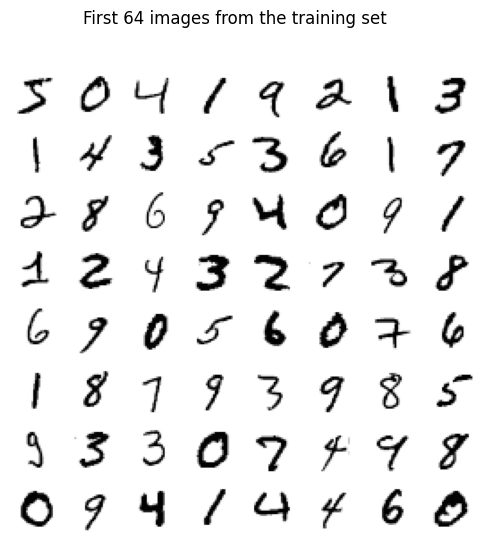

Training input shape (50000, 784); Validation input shape (10000, 784); Test input shape (10000, 784)
Training labels shape (50000,); Validation labels shape (10000,); Test labels shape (10000,)
Data Python type: Inputs <class 'numpy.ndarray'>; Labels <class 'numpy.ndarray'>
Data dtype: Inputs float32; Labels int64


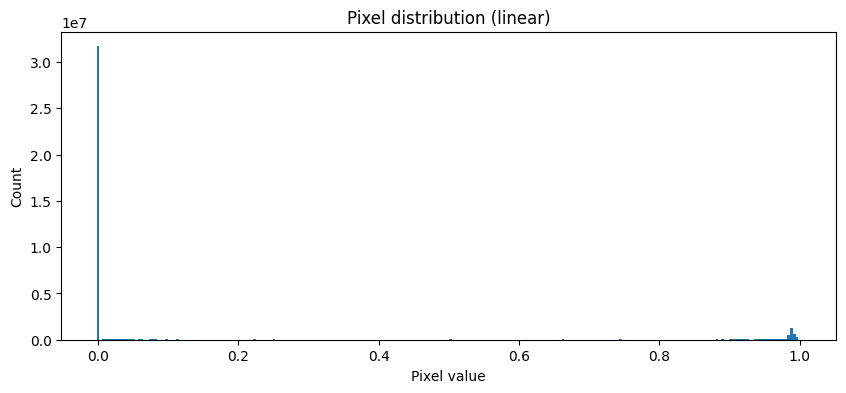

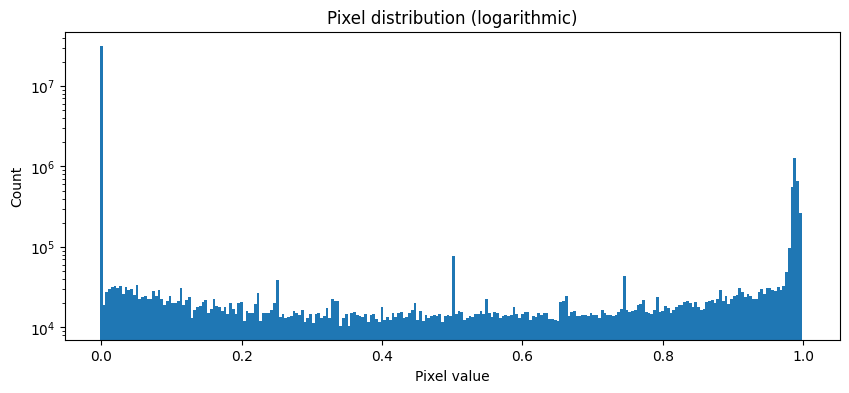

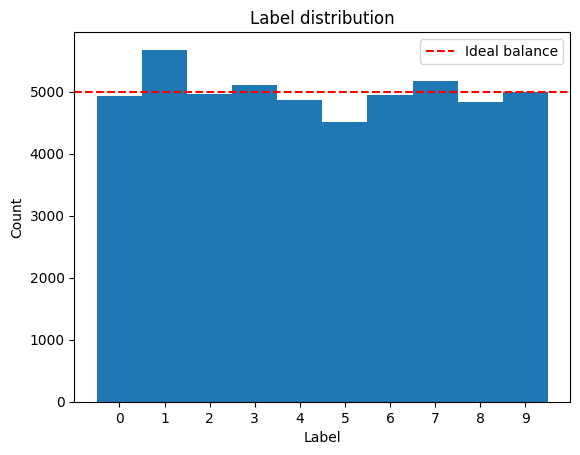

In [5]:
mnist_overview(x_train, y_train, x_valid, y_valid, x_test, y_test)

In [6]:
class Model:
    # adding hidden size here since we need to specify the number of neurons involved
    def __init__(self, hidden_size = 256):
      # weights1 is 256x784,it takes the 784 pixel values and squishes them into 256 features
      weights1 = torch.distributions.Uniform(-0.01, 0.01).sample((hidden_size, 784))
      # weights2 is 10x256, takes those 256 features and turns them into 10 scores (one per digit)
      weights2 = torch.distributions.Uniform(-0.01, 0.01).sample((10, hidden_size))
      self.parameters = [
        # [hidden_size, 784]
        weights1.requires_grad_(True),
        # bias 1
        torch.zeros(hidden_size, requires_grad=True),
        # [10, hidden_size]
        weights2.requires_grad_(True),
        # bias 2
        torch.zeros(10, requires_grad=True)
    ]

    def forward(self,
                inputs: torch.Tensor) -> torch.Tensor:
        hidden = inputs @ self.parameters[0].T + self.parameters[1]
        hidden = torch.relu(hidden)          # activation function
        logits = hidden @ self.parameters[2].T + self.parameters[3]
        return log_softmax(logits)

    def __call__(self,
                 inputs: torch.Tensor) -> torch.Tensor:
        return self.forward(inputs)

    # DIFFERENCE new function to move parameters to device
    def to(self, device: str):
        with torch.no_grad():
            for ind in range(len(self.parameters)):
                self.parameters[ind] = self.parameters[ind].to(device)
                self.parameters[ind].requires_grad = True

    @property
    def device(self):
        return self.parameters[0].device


# DIFFERENCE
def log_softmax(inputs: torch.Tensor) -> torch.Tensor:
    return inputs - torch.logsumexp(inputs, dim=1, keepdims=True)


# DIFFERENCE using log softmax outputs directly
def cross_entropy(log_outputs: torch.Tensor,
                  labels: torch.Tensor) -> torch.Tensor:
    labels_one_hot = one_hot(labels, num_classes=10)
    return -(labels_one_hot * log_outputs).sum(axis=-1).mean()


def one_hot(inputs: torch.Tensor,
            num_classes: int | None = None) -> torch.Tensor:
    if num_classes is None:
        num_classes = inputs.max() + 1
    output = torch.zeros(inputs.shape[0], num_classes, device=inputs.device)
    output.scatter_(1, inputs.view(-1, 1), torch.ones(inputs.shape[0], 1, device=inputs.device))

    return output

## MLP Model Definition

The model has two weight matrices:

- weights1 is shape (hidden_size x 784), takes the 784 pixel values as input
  and maps them to hidden_size features
- weights2 is shape (10 x hidden_size), takes those features and maps them to
  10 output scores, one per digit class

Both weight matrices are randomly initialized using a uniform distribution
between -0.01 and 0.01 to break symmetry. Biases are initialized to zero
which is fine since the weights already handle symmetry breaking.

## Why Zero Initialization Fails for MLPs

If all weights start from 0, every neuron in the hidden layer computes the exact same output
and gets the exact same gradient during backpropagation. This causes all neurons to
update in identical fashion and stay identical forever, thus a hidden layer of 256 neurons
essentially behaves like a single neuron only and the whole layer is useless.

Random initialization fixes this by giving each neuron a different starting point,
so that they can learn the different features.
     
This is not an issue for the linear model because there is no hidden layer,
the weights go directly from input to output so there is no symmetry to break.
Biases are fine to initialize to zero even in MLPs since the weights already
handle the symmetry breaking.

In [7]:
print("Indices")
print(y_train[:5])
print()
print("One-hot")
print(one_hot(torch.tensor(y_train[:5])))

Indices
[5 0 4 1 9]

One-hot
tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])


Dummy Testing the  model

Here we changed the model name to MLP model and also printed out the parameters

In [8]:

# Changing the model name to MLP model
# linear_model = Model()
mlp_model = Model()
print(mlp_model.parameters)
# using GPU
mlp_model.to(DEVICE)

with torch.no_grad():
    print(mlp_model(torch.tensor(x_train[:4]).to(DEVICE)))
with torch.no_grad():
    print(cross_entropy(mlp_model(torch.tensor(x_train[:4]).to(DEVICE)), torch.tensor(y_train[:4]).to(DEVICE)))
np.log(10)
with torch.no_grad():
    print(accuracy(mlp_model(torch.tensor(x_train[:4]).to(DEVICE)), torch.tensor(y_train[:4]).to(DEVICE)))




[tensor([[-0.0008,  0.0029, -0.0085,  ...,  0.0016, -0.0036, -0.0058],
        [ 0.0056,  0.0043,  0.0082,  ..., -0.0097, -0.0037, -0.0057],
        [-0.0065, -0.0076, -0.0018,  ...,  0.0014,  0.0015, -0.0079],
        ...,
        [-0.0063, -0.0076,  0.0070,  ...,  0.0067, -0.0033,  0.0005],
        [ 0.0011,  0.0073, -0.0050,  ...,  0.0092, -0.0053, -0.0022],
        [-0.0098, -0.0012,  0.0061,  ..., -0.0065,  0.0071,  0.0068]],
       requires_grad=True), tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0

Real Training

In [9]:
def train_mlp_model(model: Model,
                       training_data: tuple[np.ndarray, np.ndarray],
                       validation_data: tuple[np.ndarray, np.ndarray],
                       learning_rate: float,
                       batch_size: int,
                       n_epochs: int,
                       verbose: bool = True) -> dict[str, np.ndarray]:
    n_training_examples = len(training_data[0])
    batches_per_epoch = n_training_examples // batch_size
    print("Running {} epochs at {} steps per epoch.".format(n_epochs, batches_per_epoch))

    random_shuffling = np.arange(n_training_examples)

    # this moves the WHOLE dataset to the GPU!
    # this is somewhat wasteful in terms of memory and not recommended for larger datasets.
    # but MNIST is pretty small, so it's ok.
    # normally you should only move the batches to the GPU as you need them.
    # but that would be slightly slower, as copying the data takes time during the training loop.
    train_input_tensor = torch.tensor(training_data[0]).to(model.device)
    train_label_tensor = torch.tensor(training_data[1]).to(model.device)
    valid_input_tensor = torch.tensor(validation_data[0]).to(model.device)
    valid_label_tensor = torch.tensor(validation_data[1]).to(model.device)

    # note, for training we only track the average over the epoch.
    # this is somewhat imprecise, as the model changes over the epoch.
    # so the metrics at the end of the epoch will usually be better than at the start,
    # but we average over everything.
    # we could record train metrics more often to get a better picture of training progress.
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(n_epochs):
        if verbose:
            print("Starting epoch {}...".format(epoch + 1), end=" ")
        start_time = perf_counter()
        # every epoch we shuffle the data!
        np.random.shuffle(random_shuffling)  # this shuffles in place
        slice_index = 0
        shuffled_inputs = train_input_tensor[random_shuffling]
        shuffled_labels = train_label_tensor[random_shuffling]

        epoch_train_losses = []
        epoch_train_accuracies = []

        for batch_ind in range(batches_per_epoch):
            input_batch = shuffled_inputs[slice_index:slice_index+batch_size]
            label_batch = shuffled_labels[slice_index:slice_index+batch_size]
            # this is the core of model training!
            # all the other stuff is pretty much just providing data and recording metrics...
            # two lines "forward" to compute outputs and the loss
            output_batch = model(input_batch)
            batch_loss = cross_entropy(output_batch, label_batch)
            # and then backpropagate
            batch_loss.backward()
            with torch.no_grad():
                # DIFFERENCE loop over parameters
                for parameter in model.parameters:
                    parameter.sub_(parameter.grad * learning_rate)
                    parameter.grad.zero_()

            batch_accuracy = accuracy(output_batch, label_batch)
            epoch_train_losses.append(batch_loss.item())
            epoch_train_accuracies.append(batch_accuracy.item())

            slice_index += batch_size
        end_time = perf_counter()
        time_taken = end_time - start_time

        # evaluate after each epoch
        with torch.no_grad():
            val_output = model(valid_input_tensor)
            val_loss = cross_entropy(val_output, valid_label_tensor)
            val_accuracy = accuracy(val_output, valid_label_tensor)
        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy.item())

        train_losses.append(np.mean(epoch_train_losses))
        train_accuracies.append(np.mean(epoch_train_accuracies))

        if verbose:
            print(f"Time taken: {time_taken:.3f} seconds")
            print(f"\tTrain/val loss: {train_losses[-1]:.5g} / {val_losses[-1]:.5g}")
            print(f"\tTrain/val accuracy: {train_accuracies[-1]:.5g} / {val_accuracies[-1]:.5g}")
            print()

    return {"train_loss": np.array(train_losses), "train_accuracy": np.array(train_accuracies),
            "val_loss": np.array(val_losses), "val_accuracy": np.array(val_accuracies)}

In [10]:
metrics = train_mlp_model(mlp_model, (x_train, y_train), (x_valid, y_valid),
                             learning_rate=0.1, batch_size=128, n_epochs=15)

Running 15 epochs at 390 steps per epoch.
Starting epoch 1... Time taken: 0.665 seconds
	Train/val loss: 0.87956 / 0.35334
	Train/val accuracy: 0.77788 / 0.9034

Starting epoch 2... Time taken: 0.608 seconds
	Train/val loss: 0.33929 / 0.27874
	Train/val accuracy: 0.90329 / 0.9204

Starting epoch 3... Time taken: 0.537 seconds
	Train/val loss: 0.28156 / 0.2457
	Train/val accuracy: 0.91953 / 0.9279

Starting epoch 4... Time taken: 0.535 seconds
	Train/val loss: 0.24186 / 0.20964
	Train/val accuracy: 0.93057 / 0.9417

Starting epoch 5... Time taken: 0.537 seconds
	Train/val loss: 0.21113 / 0.18631
	Train/val accuracy: 0.94 / 0.9493

Starting epoch 6... Time taken: 0.548 seconds
	Train/val loss: 0.18657 / 0.16688
	Train/val accuracy: 0.94736 / 0.9544

Starting epoch 7... Time taken: 0.537 seconds
	Train/val loss: 0.16613 / 0.15404
	Train/val accuracy: 0.9528 / 0.9579

Starting epoch 8... Time taken: 0.533 seconds
	Train/val loss: 0.15028 / 0.14171
	Train/val accuracy: 0.95729 / 0.9605

Sta

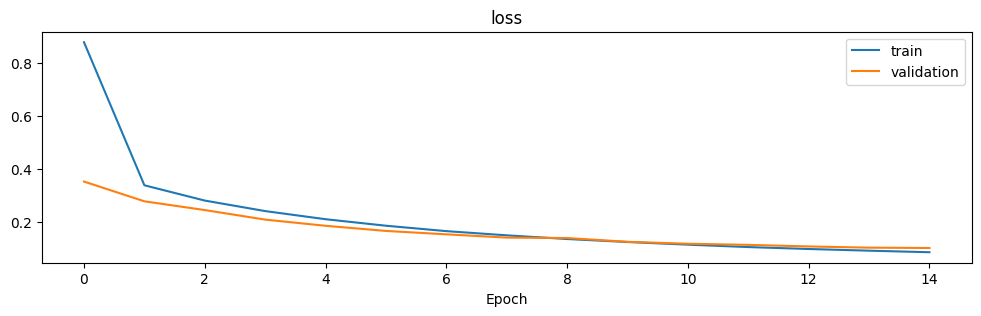

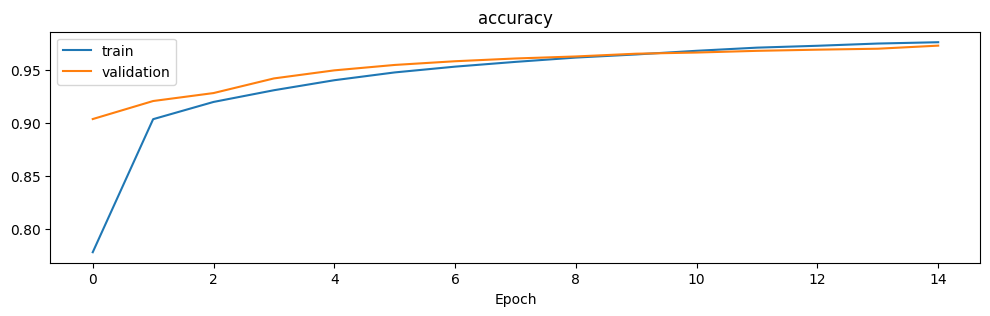

In [11]:
plot_learning_curves(metrics, keys=["loss", "accuracy"])

In [12]:
training_matrix = confusion_matrix(mlp_model, x_train, y_train, device=DEVICE)
np.set_printoptions(suppress=True)
print("Training confusion matrix")
print(training_matrix)

validation_matrix = confusion_matrix(mlp_model, x_valid, y_valid, device=DEVICE)
print()
print("Validation confusion matrix")
print(validation_matrix)

Training confusion matrix
[[4866    0    5    6    4   10   18    2   16    5]
 [   1 5569   33   15    6    1    3    8   37    5]
 [  12    7 4869   27   11    1    6   16   17    2]
 [   2    5   35 4983    0   22    4   17   21   12]
 [   3    6   13    1 4744    3   23    4   10   52]
 [  10    6    9   48    9 4375   15    4   22    8]
 [  18    5    6    2   10    9 4886    0   15    0]
 [   3   11   39   11   21    5    2 5053    8   22]
 [   8   16    8   29    3   17   13    2 4739    7]
 [  12    6    2   37   49   12    1   32   26 4811]]

Validation confusion matrix
[[ 973    0    3    1    0    0    7    1    3    3]
 [   0 1043    3    4    0    0    0    2   12    0]
 [   1    1  971    5    1    1    2    3    5    0]
 [   0    0    8 1004    0    9    0    2    6    1]
 [   0    4    2    0  960    1    1    1    1   13]
 [   2    1    6   20    2  860   12    2    7    3]
 [   3    0    2    0    2    2  955    0    3    0]
 [   1    6    5    5    3    1    0 1063  

In [13]:
print("TRAINING")
precision_recall(training_matrix)

print("\n\nVALIDATION")
precision_recall(validation_matrix)

TRAINING
Class 0
Recall: 0.98662
Precision: 0.98602
Class 1
Recall: 0.98080
Precision: 0.98899
Class 2
Recall: 0.98007
Precision: 0.97011
Class 3
Recall: 0.97687
Precision: 0.96588
Class 4
Recall: 0.97633
Precision: 0.97673
Class 5
Recall: 0.97093
Precision: 0.98204
Class 6
Recall: 0.98687
Precision: 0.98290
Class 7
Recall: 0.97643
Precision: 0.98346
Class 8
Recall: 0.97873
Precision: 0.96498
Class 9
Recall: 0.96451
Precision: 0.97705


VALIDATION
Class 0
Recall: 0.98184
Precision: 0.98882
Class 1
Recall: 0.98026
Precision: 0.98396
Class 2
Recall: 0.98081
Precision: 0.96810
Class 3
Recall: 0.97476
Precision: 0.94806
Class 4
Recall: 0.97660
Precision: 0.98059
Class 5
Recall: 0.93989
Precision: 0.97616
Class 6
Recall: 0.98759
Precision: 0.97549
Class 7
Recall: 0.97523
Precision: 0.98153
Class 8
Recall: 0.97324
Precision: 0.95712
Class 9
Recall: 0.95213
Precision: 0.96723


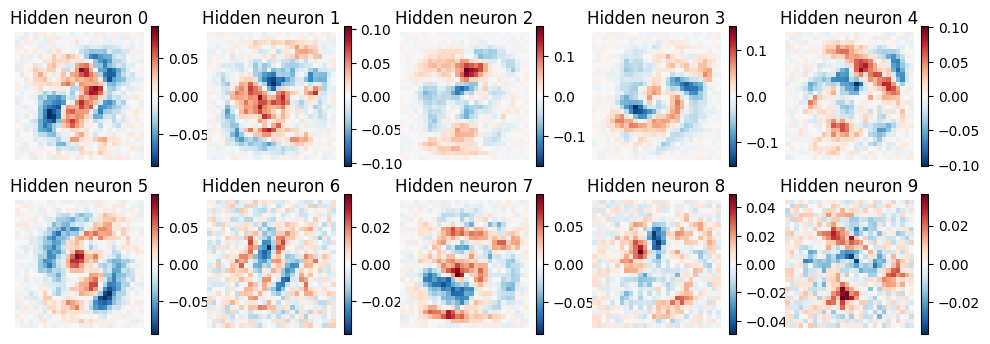

In [14]:
plt.figure(figsize=(12, 4))
for ind, pattern in enumerate(mlp_model.parameters[0].detach().cpu().numpy()[:10]):  # [:10] limits to 10
    plt.subplot(2, 5, ind+1)
    absmax = abs(pattern).max()
    plt.imshow(pattern.reshape(28, 28), vmin=-absmax, vmax=absmax, cmap="RdBu_r")
    plt.axis("off")
    plt.colorbar()
    plt.title(f"Hidden neuron {ind}")
plt.show()

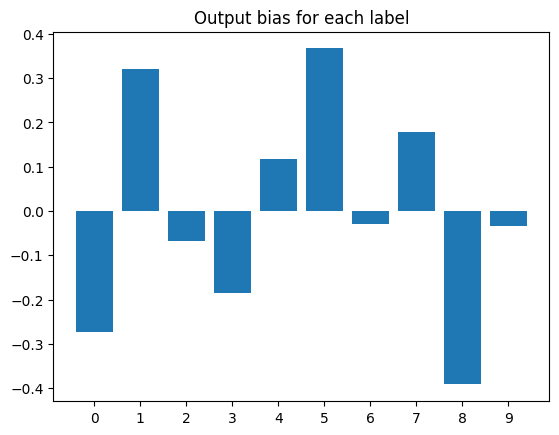

In [15]:
plt.bar(np.arange(10), mlp_model.parameters[3].detach().cpu().numpy())
plt.xticks(np.arange(10))
plt.title("Output bias for each label")
plt.show()

Hyper parameter Testing: we are trying to test with different combinations for batch size and see how they affect the final accuracy of the prediction.

In [19]:
batch_sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
results = {}

for bs in batch_sizes:
    print(f"Training with batch_size={bs}")
    model = Model(hidden_size=256)
    model.to(DEVICE)
    metrics = train_mlp_model(model, (x_train, y_train), (x_valid, y_valid),
                                 learning_rate=0.1, batch_size=bs, n_epochs=15,
                                 verbose=False)
    results[bs] = metrics
    print(f"  Final value for accuracy: {metrics['val_accuracy'][-1]:.4f}")

Training with batch_size=2
Running 15 epochs at 25000 steps per epoch.
  Final value for accuracy: 0.9603
Training with batch_size=4
Running 15 epochs at 12500 steps per epoch.
  Final value for accuracy: 0.9777
Training with batch_size=8
Running 15 epochs at 6250 steps per epoch.
  Final value for accuracy: 0.9827
Training with batch_size=16
Running 15 epochs at 3125 steps per epoch.
  Final value for accuracy: 0.9810
Training with batch_size=32
Running 15 epochs at 1562 steps per epoch.
  Final value for accuracy: 0.9789
Training with batch_size=64
Running 15 epochs at 781 steps per epoch.
  Final value for accuracy: 0.9779
Training with batch_size=128
Running 15 epochs at 390 steps per epoch.
  Final value for accuracy: 0.9724
Training with batch_size=256
Running 15 epochs at 195 steps per epoch.
  Final value for accuracy: 0.9585
Training with batch_size=512
Running 15 epochs at 97 steps per epoch.
  Final value for accuracy: 0.9387
Training with batch_size=1024
Running 15 epochs a

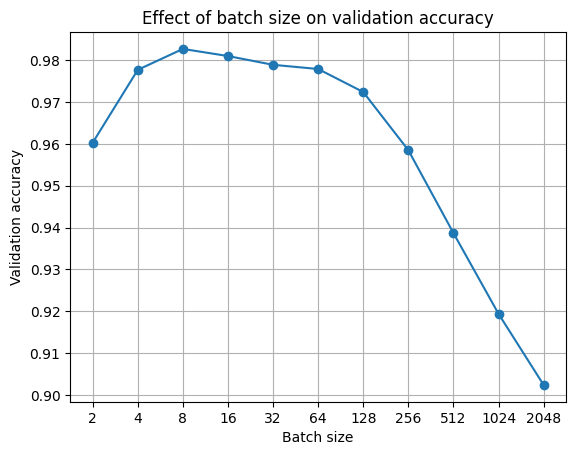

In [21]:
val_accs = [results[bs]['val_accuracy'][-1] for bs in batch_sizes]

plt.figure()
plt.plot(batch_sizes, val_accs, marker='o')
plt.xscale('log', base=2)
plt.xticks(batch_sizes, labels=[str(bs) for bs in batch_sizes])
plt.xlabel("Batch size")
plt.ylabel("Validation accuracy")
plt.title("Effect of batch size on validation accuracy")
plt.grid(True)
plt.show()




## Inference

When batch size is  very small (2,4) the accuracy is poor, it however gradually rises when increasing the batch size to 8 (maximum value) after which it again dips for further increases.

Note: this is only a study for hyperparameter - batch size when the  rest of the values for other hyperparameters are kept fixed this might change when other hyperparams are changed. We would need to use a hyperparameter optimisation algorithm to find the best values for hyperparams for this model to achieve best results.

## Reflection on PyTorch's Low-Level Interface

what should be wrapped:
- parameter management — having a list of parameters and manually looping over them
  to update gradients is annoying, if you add a new layer you will have to remember to change accordingly in all related areas or you might run into errors
- Gradient zeroing — calling `grad.zero_()` after every batch update should be automated, its the same every time and redundant.
- device handling — having to `.to(DEVICE)` in many areas when switching to GPU mode is really difficult, kept running into errors this way.
- the forward pass, loss computation, backward pass and parameter
  update follows the exact same pattern for every model, this can be wrapped
- If you change hidden_size in one place without updating the other it will lead to crashes

what is missing:
- no easy save/load for the model
- no train/eval mode switching
- tracking metrics is all manual, have to write it yourself every time

overall writing everything from scratch was good for understanding whats actually important but it is very difficult and tiring and time consuming as well. The code  is  very long and difficult to interpret.